# Custom Candidate Function

One more possible requirement might be to automatically select the next speaker from a filtered list of agents. For this, we can set `candidate_func` parameter with a "custom candidate function" to filter down the list of potential agents for speaker selection for each turn of groupchat.

This allow us to restrict speaker selection to a specific set of agents after a given agent.

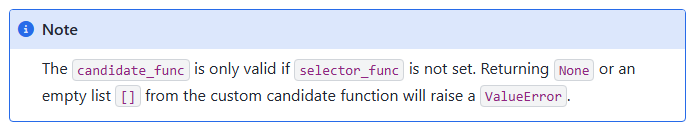

#### ***Reference URL***

https://microsoft.github.io/autogen/stable//user-guide/agentchat-user-guide/selector-group-chat.html#custom-candidate-function

In [ ]:
def candidate_func(messages: Sequence[BaseAgentEvent | BaseChatMessage]) -> List[str]:
    # keep planning_agent first one to plan out the tasks
    if messages[-1].source == "user":
        return [planning_agent.name]

    # if previous agent is planning_agent and if it explicitely asks for web_search_agent
    # or data_analyst_agent or both (in-case of re-planning or re-assignment of tasks)
    # then return those specific agents
    last_message = messages[-1]
    if last_message.source == planning_agent.name:
        participants = []
        if web_search_agent.name in last_message.to_text():
            participants.append(web_search_agent.name)
        if data_analyst_agent.name in last_message.to_text():
            participants.append(data_analyst_agent.name)
        if participants:
            return participants  # SelectorGroupChat will select from the remaining two agents.

    # we can assume that the task is finished once the web_search_agent
    # and data_analyst_agent have took their turns, thus we send
    # in planning_agent to terminate the chat
    previous_set_of_agents = set(message.source for message in messages)
    if web_search_agent.name in previous_set_of_agents and data_analyst_agent.name in previous_set_of_agents:
        return [planning_agent.name]

    # if no-conditions are met then return all the agents
    return [planning_agent.name, web_search_agent.name, data_analyst_agent.name]


# Reset the previous team and run the chat again with the selector function.
await team.reset()
team = SelectorGroupChat(
    [planning_agent, web_search_agent, data_analyst_agent],
    model_client=model_client,
    termination_condition=termination,
    candidate_func=candidate_func,
)

await Console(team.run_stream(task=task))
